In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize


In [3]:
current_holdings = {
    'ETH-USD': 686,
    'SOL-USD': 62,
    'AMD': 122,
    'URA': 159,
    'PANW': 4,
    'TX': 2,
}

candidates = ['EWJ','FSLR','YPF','GS','HSBC']

all_tickers = list(current_holdings.keys())+candidates

print(f"Downloading data for: {all_tickers}")
raw_data = yf.download(all_tickers, start="2024-01-01", end="2026-01-20", group_by='column', auto_adjust = False)

try:
    if 'Adj Close' in raw_data.columns:
        data = raw_data['Adj Close']
    else:
        data = raw_data
    
    data = data.ffill().dropna()

    print("\nSuccess! Data shape:", data.shape)
    print(data.head())

except KeyError as e:
    print(f"\nStructure Error: {e}")
    print("Columns are:", raw_data.columns)

[*********************100%***********************]  11 of 11 completed


Success! Data shape: (749, 11)
Ticker             AMD      ETH-USD        EWJ        FSLR          GS  \
Date                                                                     
2024-01-02  138.580002  2355.836426  59.401604  172.160004  371.533905   
2024-01-03  135.320007  2210.761963  59.074497  167.419998  365.305023   
2024-01-04  136.009995  2269.038086  58.934311  166.309998  366.414978   
2024-01-05  138.580002  2268.647217  59.373569  166.869995  369.754272   
2024-01-06  138.580002  2241.624756  59.373569  166.869995  369.754272   

Ticker           HSBC        PANW     SOL-USD         TX        URA        YPF  
Date                                                                            
2024-01-02  34.477882  144.460007  106.611221  36.064842  25.189423  16.520000  
2024-01-03  34.374760  143.235001   98.594437  35.735638  24.910883  16.770000  
2024-01-04  34.641163  141.649994  105.077538  35.952217  25.254417  16.230000  
2024-01-05  35.010693  141.464996   99.97879

In [5]:
log_returns = np.log(data/data.shift(1))
log_returns = log_returns.dropna()

print("Log Returns Shape", log_returns.shape)
log_returns.head()

Log Returns Shape (748, 11)


Ticker,AMD,ETH-USD,EWJ,FSLR,GS,HSBC,PANW,SOL-USD,TX,URA,YPF
Date,,,,,,,,,,,
2024-01-03,-0.023805,-0.063559,-0.005522,-0.027919,-0.016907,-0.002995,-0.008516,-0.078174,-0.009170,-0.011119,0.015020
2024-01-04,0.005086,0.026019,-0.002376,-0.006652,0.003034,0.007720,-0.011127,0.063684,0.006042,0.013696,-0.032730
2024-01-05,0.018719,-0.000172,0.007426,0.003362,0.009072,0.010611,-0.001307,-0.049740,-0.019711,-0.008863,0.028547
2024-01-06,0.000000,-0.011983,0.000000,0.000000,0.000000,0.000000,0.000000,-0.063178,0.000000,0.000000,0.000000
2024-01-07,0.000000,-0.008404,0.000000,0.000000,0.000000,0.000000,0.000000,-0.050043,0.000000,0.000000,0.000000


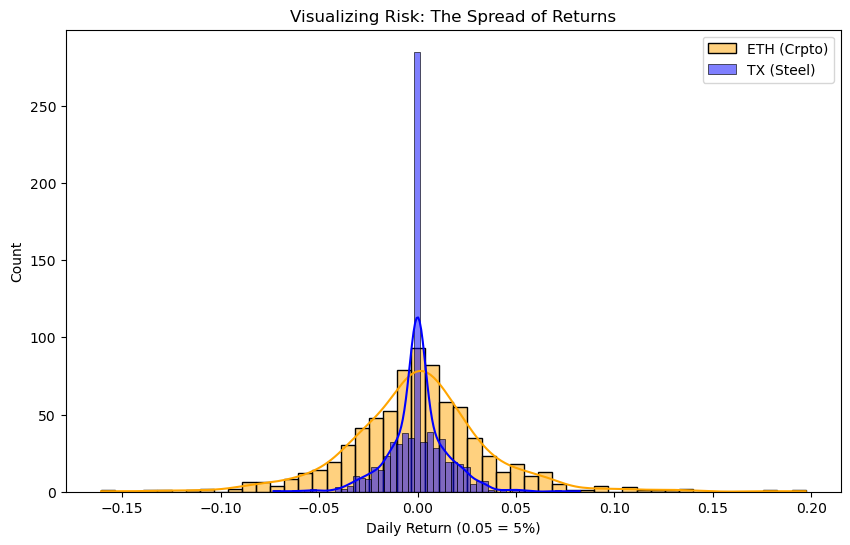

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(log_returns['ETH-USD'],bins=50,kde=True, color='orange', label='ETH (Crpto)', alpha=0.5)

sns.histplot(log_returns['TX'],bins=50,kde=True, color='blue', label='TX (Steel)', alpha=0.5)

plt.title("Visualizing Risk: The Spread of Returns")
plt.xlabel("Daily Return (0.05 = 5%)")
plt.legend()
plt.show()

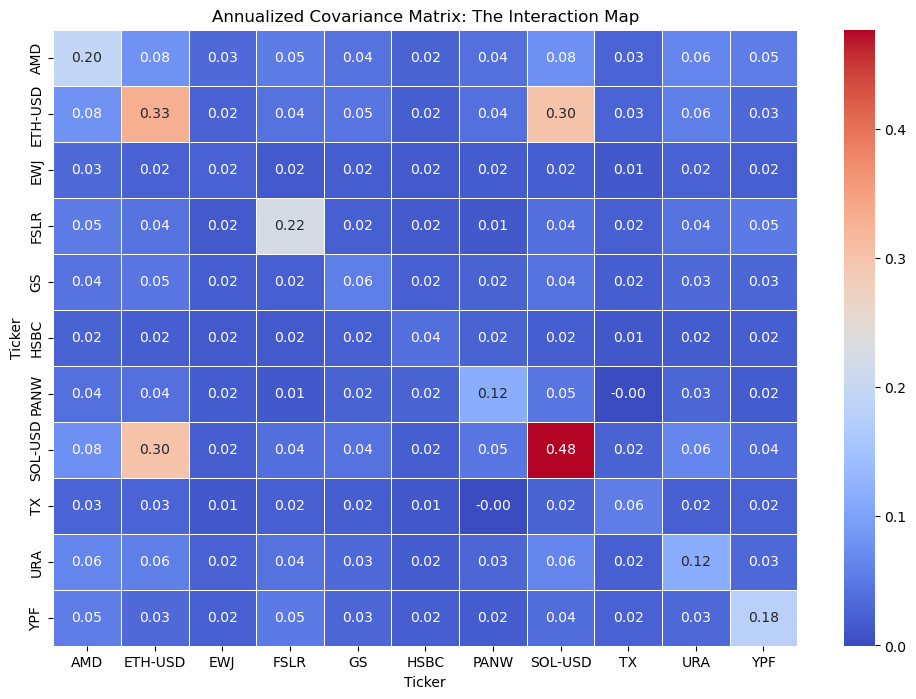


Covariance Matrix (Annualized)


Ticker,AMD,ETH-USD,EWJ,FSLR,GS,HSBC,PANW,SOL-USD,TX,URA,YPF
Ticker,,,,,,,,,,,
AMD,0.195204,0.078907,0.032226,0.053543,0.041036,0.024759,0.039148,0.077233,0.026292,0.064526,0.053920
ETH-USD,0.078907,0.331271,0.022199,0.042070,0.045933,0.019579,0.039560,0.300513,0.027197,0.056289,0.033048
EWJ,0.032226,0.022199,0.024009,0.015410,0.019489,0.015550,0.016839,0.019663,0.013149,0.023773,0.020937
FSLR,0.053543,0.042070,0.015410,0.223646,0.020842,0.015250,0.013396,0.038677,0.020924,0.042583,0.050410
GS,0.041036,0.045933,0.019489,0.020842,0.056133,0.020825,0.024479,0.042515,0.018955,0.033081,0.028576


In [6]:
covar_matrix= log_returns.cov() * 252

plt.figure(figsize=(12,8))
sns.heatmap(covar_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidths=.5)
plt.title("Annualized Covariance Matrix: The Interaction Map")
plt.show()
print("\nCovariance Matrix (Annualized)")
covar_matrix.head()

In [9]:
valid_tickers = [t for t in current_holdings.keys() if t in data.columns]
current_values = np.array([current_holdings[t]for t in valid_tickers])
current_total = np.sum(current_values)
current_weights = current_values / current_total

full_currnet_weights = np.array([current_holdings.get(ticker,0)/current_total for ticker in data.columns])

baseline_return = np.sum(log_returns.mean() * full_currnet_weights)*252

baseline_variance = np.dot(full_currnet_weights.T,np.dot(covar_matrix, full_currnet_weights))
baseline_volatility = np.sqrt(baseline_variance)

print("---SATTUS QUO (Current Portfolio)---")
print(f"Total Invested: ${current_total:.0f}")
print(f"Annual Volatility (Risk): {baseline_volatility:.2%}")
print(f"Naive Annual Return: {baseline_return:.2%}")
print(f"Sharpe Ratio: {baseline_return/baseline_volatility:.2f}")

def portfolio_volatility(weights, covar_matrix):
    return np.sqrt(np.dot(weights.T,np.dot(covar_matrix, weights)))

num_assets = len(data.columns)
initial_guess = [1/num_assets]*num_assets
bounds = tuple((0,1)for _ in range(num_assets))
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x)-1})

result = minimize(portfolio_volatility,initial_guess,args=(covar_matrix),method = 'SLSQP',bounds=bounds,constraints = constraints)

min_vol_weights = result.x
min_volatility = result.fun

print("\n---OPTIMIZED MODEL ( Minimun Variance) ---")
print(f"Minimun Possible Volatility: {min_volatility:.2%}")
print(f"Risk Reduction: {baseline_volatility-min_volatility:.2%}")

comparison_df = pd.DataFrame({'Asset':data.columns,'Your Current Allocation': full_currnet_weights, 'Optimized Allocation': min_vol_weights})

comparison_df = comparison_df[comparison_df['Optimized Allocation']>0.001]
comparison_df['Your Current Allocation']= comparison_df['Your Current Allocation'].apply(lambda x: f"{x:.1%}")
comparison_df['Optimized Allocation'] = comparison_df['Optimized Allocation'].apply(lambda x: f"{x:.1%}")

print("\nAlloction Comparison:")
print(comparison_df)

---SATTUS QUO (Current Portfolio)---
Total Invested: $1035
Annual Volatility (Risk): 45.32%
Naive Annual Return: 13.27%
Sharpe Ratio: 0.29

---OPTIMIZED MODEL ( Minimun Variance) ---
Minimun Possible Volatility: 14.12%
Risk Reduction: 31.20%

Alloction Comparison:
  Asset Your Current Allocation Optimized Allocation
2   EWJ                    0.0%                56.1%
3  FSLR                    0.0%                 1.8%
4    GS                    0.0%                 0.2%
5  HSBC                    0.0%                20.2%
6  PANW                    0.4%                 4.5%
8    TX                    0.2%                17.3%
